# Assignment

# Boosting techniques Q&A

## Theory Base Questions

1.  What is Boosting in Machine Learning? Explain how it improves weak learners.
- Boosting is an ensemble machine learning technique that converts weak learners—models with low predictive power—into a single strong learner. It trains models sequentially, where each new model focuses heavily on correcting the errors (misclassified data points) of the previous model, resulting in high accuracy and reduced variance. 
- Boosting improves performance through an iterative, sequential approach rather than training models in parallel. 
  - Sequential Learning: Unlike techniques like Random Forest (which trains trees independently), boosting builds models (often shallow decision trees or "stumps") one after another.
  - Focus on Errors (Weighted Data): In each iteration, the algorithm assigns higher weights to data points that were incorrectly classified by the previous model. The next model is forced to focus on these difficult cases to improve.
  - Additive Combination: The final model is a weighted sum of all the weak learners. Models that perform better generally get more say in the final prediction.
  
2.  What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
- AdaBoost and Gradient Boosting both build models sequentially, but differ in how they correct errors: AdaBoost increases the weights of misclassified data points to focus subsequent "stumps" (shallow trees) on hard cases. Gradient Boosting fits new models to the residuals (errors) of previous models using gradient descent to minimize loss.

3. How does regularization help in XGBoost? 
- Regularization in XGBoost acts as a penalty on complex models—specifically on leaf weights and tree depth—to prevent overfitting and improve generalization on unseen data. By incorporating L1 (Lasso) and L2 (Ridge) penalties, XGBoost shrinks leaf scores towards zero, creating simpler, more robust trees.

4. Why is CatBoost considered efficient for handling categorical data? 
- CatBoost is considered highly efficient for categorical data because it natively handles these features without needing manual preprocessing (like one-hot encoding), which prevents high-cardinality issues and reduces memory usage. It uses innovative techniques like Ordered Target Encoding to prevent data leakage and oblivious trees for faster training, providing robust, high-performance results out-of-the-box.

5. What are some real-world applications where boosting techniques are preferred over bagging methods? 
- Boosting techniques (e.g., XGBoost, AdaBoost) are preferred over bagging (e.g., Random Forest) when maximizing predictive accuracy is critical, or when reducing high bias is necessary. They are ideal for high-stakes, noisy tasks such as financial fraud detection, credit scoring, medical disease prediction, and customer churn analysis.

## Practical Questions

In [1]:
#6. Write a Python program to: 
# ● Train an AdaBoost Classifier on the Breast Cancer dataset 
# ● Print the model accuracy 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("AdaBoost Classifier Accuracy:", accuracy)

AdaBoost Classifier Accuracy: 0.9824561403508771


In [2]:
#7.  Write a Python program to: 
# ● Train a Gradient Boosting Regressor on the California Housing dataset 
# ● Evaluate performance using R-squared score 

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R-squared (R²) Score:", r2)

R-squared (R²) Score: 0.7803012822391022


In [2]:
#8.  Write a Python program to: 
# ● Train an XGBoost Classifier on the Breast Cancer dataset 
# ● Tune the learning rate using GridSearchCV 
# ● Print the best parameters and accuracy 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Parameter grid (tuning learning rate)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.1}
Test Accuracy: 0.9590643274853801


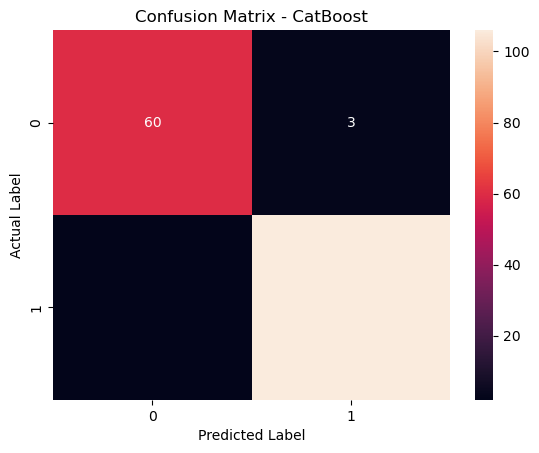

In [1]:
#9. Write a Python program to: 
# ● Train a CatBoost Classifier 
# ● Plot the confusion matrix using seaborn 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,   # suppress training output
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - CatBoost")
plt.show()

10. You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features. Describe your step-by-step data science pipeline using boosting techniques: 
● Data preprocessing & handling missing/categorical values 
● Choice between AdaBoost, XGBoost, or CatBoost 
● Hyperparameter tuning strategy 
● Evaluation metrics you'd choose and why 
● How the business would benefit from your model

- Boosting techniques can be effectively applied to predict loan defaults in an imbalanced dataset with mixed features. Initially, missing values are handled using mean/median for numerical data and mode or “Unknown” for categorical variables. Categorical features are encoded using One-Hot Encoding, while class imbalance is addressed using techniques like SMOTE or class weighting. Among boosting methods, CatBoost is preferred due to its ability to handle categorical data directly, while XGBoost is suitable for high performance and efficiency. Hyperparameters such as learning rate, number of estimators, and maximum depth are tuned using GridSearchCV with cross-validation to prevent overfitting. Since the dataset is imbalanced, evaluation metrics like Precision, Recall, F1-score, and ROC-AUC are used instead of accuracy, with emphasis on recall to identify defaulters. This model provides business value by reducing financial risk, improving credit decisions, and enabling data-driven strategies for better profitability.